### Plotting Weather Data
At the dates/times of data collection <p>
PB 01/29/23

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from datetime import datetime
from dotenv import load_dotenv
import os

# load relevant file paths from .env file
load_dotenv()

# set all your file paths
DATADIR = os.getenv("DATADIR")
FIGDIR = os.getenv("FIGDIR")
STATSDIR = os.getenv("STATSDIR")
OUTDIR = os.getenv("OUTDIR")
TRAJDIR = os.getenv("TRAJDIR")

weatherf = Path(f'{DATADIR}/in/WeatherData_ThermalLandscapes_curated_v2.csv')

df = pd.read_csv(weatherf)
# df.head()

# List out Sites in Order (top to bottom) for plotting
sites = ['Letaba', 'Nkhulu', 'Hlangwine', 'Roan Camp', 'Buffalo Camp', 'Makhohlola']

# Make lists of start and stop times for data acquisitions
# In same order as above and in local SA time (GMT+2)
starts = ['9:08', '7:56', '9:38', '8:51', '8:41', '10:11']
# NOTE: missing stop time for hlangwine
#Also, these are rough estimates, need to double check or get individual image times
stops = ['10:25', '15:25', '00:00', '11:38', '9:44', '10:48']

# convert to datetime
starts_dt = [datetime.strptime(t, '%H:%M') for t in starts]
stops_dt = [datetime.strptime(t, '%H:%M') for t in stops]

In [2]:
df.head()

,Station,Date,Time,Tdry_C,Max_Tdry_C,Min_Tdry_C,Rhum_Perc,Dewpoint_C,Rain_mm,WSpd_kmh,...,Min_WSpd_kmh,Leaf_Wet_Perc,Srad_mJ,Sun_Hours,Eto_mm,Absolute_RH_gm3,Specific_RH_gkg,Battery,Data_type,Site
0,Skukuza,1/16/2020,1:00,22.73,0.0,0.0,95.3,21.94,0.0,0.18,...,0.18,0,3.9,1.0,0.74,19.37,18.26,4.12,Logger,Nkuhlu
1,Skukuza,1/16/2020,2:00,23.74,0.0,0.0,91.0,22.18,0.0,1.44,...,1.44,0,3.9,1.0,0.73,19.64,18.56,4.12,Logger,Nkuhlu
2,Skukuza,1/16/2020,3:00,24.03,0.0,0.0,89.1,22.12,0.0,0.65,...,0.65,0,3.9,1.0,0.75,19.57,18.50,4.12,Logger,Nkuhlu
3,Skukuza,1/16/2020,4:00,24.02,0.0,0.0,88.1,21.93,0.0,1.48,...,1.48,0,3.9,1.0,0.74,19.36,18.29,4.12,Logger,Nkuhlu
4,Skukuza,1/16/2020,5:00,23.64,0.0,0.0,88.1,21.55,0.0,1.69,...,1.69,0,3.9,1.0,0.73,18.94,17.86,4.12,Logger,Nkuhlu


In [3]:
df.columns

Index(['Station', 'Date', 'Time', 'Tdry_C', 'Max_Tdry_C', 'Min_Tdry_C',
       'Rhum_Perc', 'Dewpoint_C', 'Rain_mm', 'WSpd_kmh', 'Wind_Degrees',
       'Wind_Direction', 'Max WSpd km/h', 'Min_WSpd_kmh', 'Leaf_Wet_Perc',
       'Srad_mJ', 'Sun_Hours', 'Eto_mm', 'Absolute_RH_gm3', 'Specific_RH_gkg',
       'Battery', 'Data_type', 'Site'],
      dtype='object')

In [4]:
# Define Settings for Plotting

# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.1, style="ticks", rc=custom_params)

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]


In [5]:
sites

['Letaba', 'Nkhulu', 'Hlangwine', 'Roan Camp', 'Buffalo Camp', 'Makhohlola']

In [6]:
df.Site.unique()

array(['Nkuhlu', 'Buffalo Camp', 'Hlangwine', 'Makhohlola', 'Roan Camp',
       'Letaba'], dtype=object)

/tmp/ipykernel_1510977/362447439.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


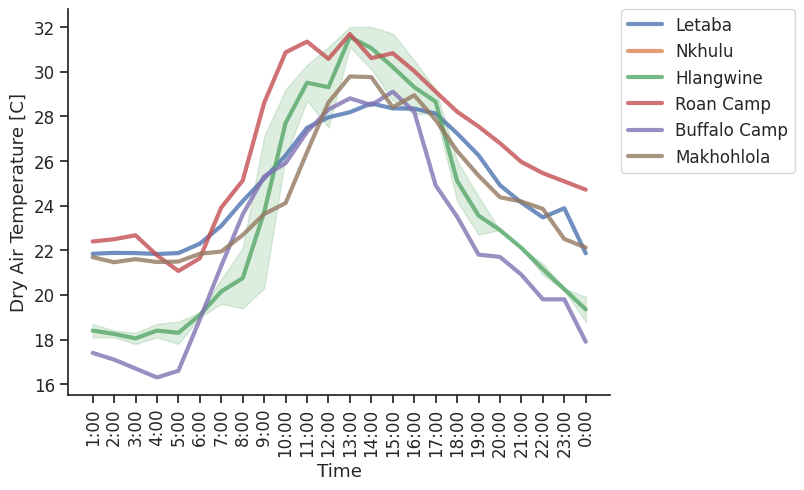

In [7]:
# Plot weather data over the course of the day

fig, ax = plt.subplots()

sns.lineplot(data=df, x='Time', y='Tdry_C', hue='Site', hue_order=sites, lw=3, alpha=0.8)

ax.set_ylabel('Dry Air Temperature [C]')
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
    # ax.vlines()
    
fig.savefig(f'{FIGDIR}/LinePlot_WeatherData_DryAirTemp.png', dpi=300)

/tmp/ipykernel_1510977/1388883598.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


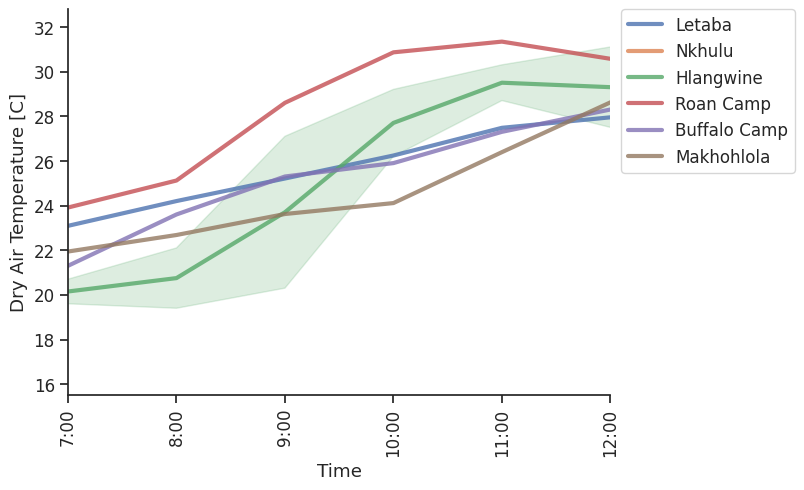

In [8]:
# Plot weather data over the course of the day

fig, ax = plt.subplots()

sns.lineplot(data=df, x='Time', y='Tdry_C', hue='Site', hue_order=sites, lw=3, alpha=0.8)

ax.set_ylabel('Dry Air Temperature [C]')
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Limit x axis to the times we flew (~ 7am - 12)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.set_xlim(6, 11)

fig.savefig(f'{FIGDIR}/LinePlot_WeatherData_DryAirTemp_xlimited.png', dpi=300)

/tmp/ipykernel_1510977/1500834266.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


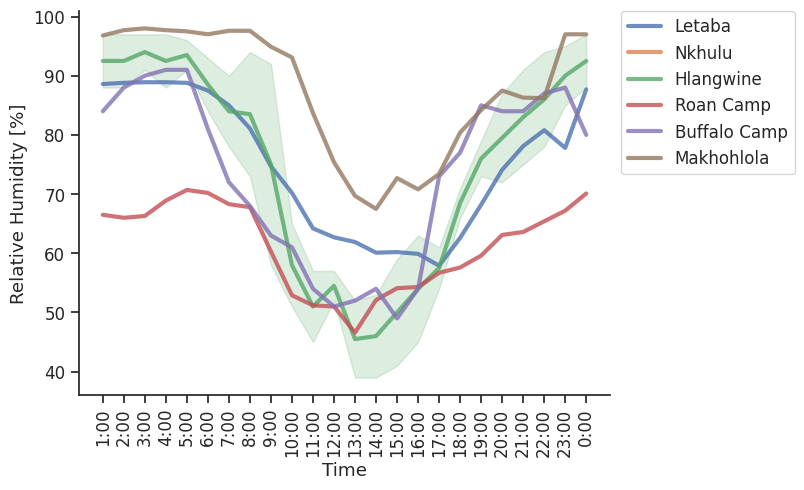

In [9]:
# Plot weather data over the course of the day

fig, ax = plt.subplots()

sns.lineplot(data=df, x='Time', y='Rhum_Perc', hue='Site', hue_order=sites, lw=3, alpha=0.8)

ax.set_ylabel('Relative Humidity [%]')
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

fig.savefig(f'{FIGDIR}/LinePlot_WeatherData_Rhumid.png', dpi=300)

/tmp/ipykernel_1510977/2282760089.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


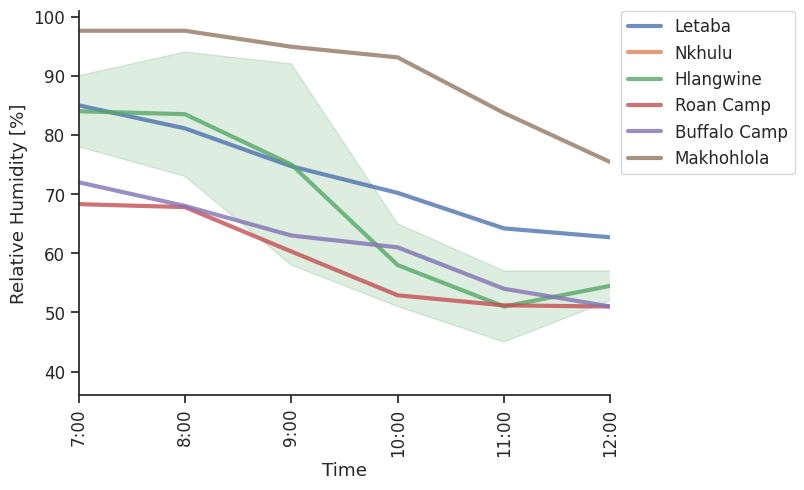

In [10]:
# Plot weather data over the course of the day

fig, ax = plt.subplots()

sns.lineplot(data=df, x='Time', y='Rhum_Perc', hue='Site', hue_order=sites, lw=3, alpha=0.8)

ax.set_ylabel('Relative Humidity [%]')
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
# ax.vlines()
ax.set_xlim(6, 11)

fig.savefig(f'{FIGDIR}/LinePlot_WeatherData_Rhumid_xlimited.png', dpi=300)

In [12]:
df.columns

Index(['Station', 'Date', 'Time', 'Tdry_C', 'Max_Tdry_C', 'Min_Tdry_C',
       'Rhum_Perc', 'Dewpoint_C', 'Rain_mm', 'WSpd_kmh', 'Wind_Degrees',
       'Wind_Direction', 'Max WSpd km/h', 'Min_WSpd_kmh', 'Leaf_Wet_Perc',
       'Srad_mJ', 'Sun_Hours', 'Eto_mm', 'Absolute_RH_gm3', 'Specific_RH_gkg',
       'Battery', 'Data_type', 'Site'],
      dtype='object')

ValueError: Could not interpret value `STDR` for `y`. An entry with this name does not appear in `data`.

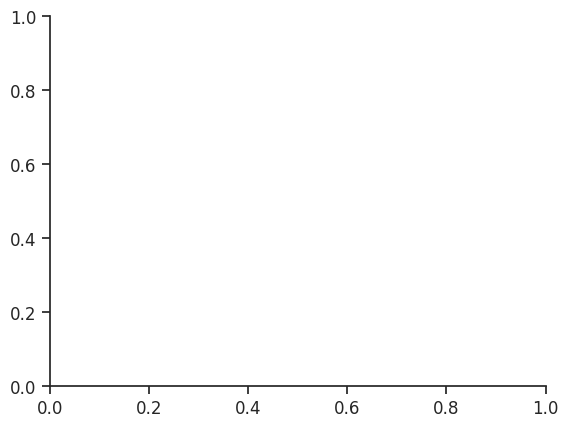

In [11]:
# Plot weather data over the course of the day

fig, ax = plt.subplots()

sns.lineplot(data=df, x='Time', y='STDR', hue='Site', hue_order=sites, lw=3, alpha=0.8)

ax.set_ylabel('Solar Downwave Radiation (j/m2)')
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
# ax.vlines()
ax.set_xlim(6, 11)

fig.savefig(f'{FIGDIR}/LinePlot_WeatherData_STDR_xlimited.png', dpi=300)

In [ ]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, sharex=True, sharey=True)

for s, start, ax in zip(sites, starts_dt, [ax1, ax2, ax3, ax4, ax5, ax6]):
    
    sns.lineplot(data=df.loc[df.Site == s],
                 x='Time', y='Tdry_C', ax=ax)
    
    if s in ['Letaba']:
        ax.set_ylabel('Dry Air Temperature [C]')
    else:
        ax.set_ylabel('')
        
    if s == 'Buffalo Camp':
        ax.set_xlabel('Time')
    else:
        ax.set_xlabel('')
        
        # Tried to draw vlines at start times, but noluck
    # ax.axvline(start)
    
    ax.set_title(s)
    
    if s in ['Roan Camp', 'Buffalo Camp', 'Makhohlola']:
        plt.xticks(rotation=90)
#         ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
        
plt.tight_layout()